# student data
this notebook analyizes pass/fail data for a class

In [2]:
data = [50, 50, 47, 65, 72, 38, 81, 55, 49, 90, 44, 67, 73, 52, 35, 60, 48, 77, 58, 42, 85, 51, 46, 69, 33, 74, 62, 57, 40, 88]
print(data * 2)

[50, 50, 47, 65, 72, 38, 81, 55, 49, 90, 44, 67, 73, 52, 35, 60, 48, 77, 58, 42, 85, 51, 46, 69, 33, 74, 62, 57, 40, 88, 50, 50, 47, 65, 72, 38, 81, 55, 49, 90, 44, 67, 73, 52, 35, 60, 48, 77, 58, 42, 85, 51, 46, 69, 33, 74, 62, 57, 40, 88]


In [3]:
import numpy as np

grades = np.array(data)

print(grades * 2)

[100 100  94 130 144  76 162 110  98 180  88 134 146 104  70 120  96 154
 116  84 170 102  92 138  66 148 124 114  80 176]


In [4]:
grades.shape

(30,)

In [5]:
grades[7]

np.int64(55)

In [6]:
grades.mean()

np.float64(58.6)

In [7]:
study_hours = [5.0, 4.10, 3.07, 7.23, 8.45, 2.0, 9.12, 6.0, 4.0, 10.15, 3.45, 7.12, 8.23, 5.75, 2.0, 6.0, 4.0,
    9.0, 6.0, 3.15, 10.65, 5.0, 4.0, 7.0, 2.25, 8.45, 6.45, 5.55, 3.55, 9.0]

student_data = np.array([study_hours, grades])

In [8]:
student_data[1][0]

np.float64(50.0)

In [9]:
avg_study = student_data[0].mean()
avg_grade = student_data[1].mean()

print(f'Average Study Time: {avg_study}\nAverage Grade: {avg_grade}')



Average Study Time: 5.857333333333332
Average Grade: 58.6


In [10]:
import pandas as pd 

df_students = pd.DataFrame({'Name': ['John', 'Mary', 'Peter', 'David', 'Sarah', 'Michael', 'Grace', 'Daniel', 'Emily', 'James',
                                    'Sophia', 'William', 'Olivia', 'Benjamin', 'Chloe', 'Samuel', 'Jessica', 'Alexander', 'Emma', 'Matthew',
                                    'Ava', 'Joseph', 'Mia', 'Henry', 'Isabella', 'Noah', 'Amelia', 'Lucas', 'Charlotte', 'Ethan'],
                            'StudyHours':student_data[0],
                            'Grade':student_data[1]})

df_students

,Name,StudyHours,Grade
0,John,5.00,50.0
1,Mary,4.10,50.0
2,Peter,3.07,47.0
3,David,7.23,65.0
4,Sarah,8.45,72.0
5,Michael,2.00,38.0
6,Grace,9.12,81.0
7,Daniel,6.00,55.0
8,Emily,4.00,49.0
9,James,10.15,90.0


In [11]:
df_students.loc[10, 'Name']

'Sophia'

In [12]:
df_students.loc[df_students['Name']=='Sophia']

,Name,StudyHours,Grade
10,Sophia,3.45,44.0


In [13]:
df_students.query('Name=="Emma"')

,Name,StudyHours,Grade
18,Emma,6.0,58.0


In [14]:
url = "https://raw.githubusercontent.com/mahaveergautamji/Data-Project/main/data/student_dataset_v2.csv" 

In [15]:
df_student = pd.read_csv(url, delimiter=',', header='infer')

df_student = df_student[['Student_Name', 'Study_Hours', 'Marks']].head(22)

df_student

,Student_Name,Study_Hours,Marks
0,Mohit Gupta,10.8,97.0
1,Vivaan Kapoor,7.6,70.0
2,Aarush Shah,11.1,76.0
3,Dhruv Kumar,2.0,100.0
4,Siddharth Gupta,3.2,NaN
5,Karan Kapoor,1.5,48.0
6,Deepak Nair,4.6,59.0
7,Sai Reddy,5.3,-20.0
8,Riya Verma,4.0,29.0
9,Vivaan Singh,10.1,74.0


In [16]:
df_student.isnull().sum()

Student_Name    0
Study_Hours     1
Marks           1
dtype: int64

In [17]:
df_student.Study_Hours = df_student.Study_Hours.fillna(df_student.Study_Hours.mean())

In [18]:
df_student = df_student.dropna(axis=0)

In [19]:
# Get the mean study hours using to column name as an index 
mean_study = df_student['Study_Hours'].mean()

# Get the mean marks using the column name as a property (just to make a point)
mean_marks = df_student.Marks.mean()

# print the mean study hours and mean marks 
print('Average weekly study hours: {:.2f}\nAverage marks: {: 2f}'.format(mean_study, mean_marks))

Average weekly study hours: 7.23
Average marks:  63.095238


In [20]:
df_student[df_student.Study_Hours > mean_study].Marks.mean()

np.float64(72.0)

In [21]:
import pandas as pd

passed = pd.Series(df_student.Marks >= 60)
df_student = pd.concat([df_student, passed.rename('Passed')], axis=1)

In [22]:
df_student.groupby(df_student.Passed).Student_Name.count()

Passed
False     9
True     12
Name: Student_Name, dtype: int64

In [23]:
print(df_student.groupby(df_student.Passed).Marks.mean())

Passed
False    39.333333
True     80.916667
Name: Marks, dtype: float64


In [24]:
df_student.groupby(df_student.Passed)[['Study_Hours', 'Marks']].mean()

,Study_Hours,Marks
Passed,,
False,5.426984,39.333333
True,8.575000,80.916667


In [25]:
df_student = df_student.sort_values('Marks', ascending=True)

In [26]:
import pandas as pd 

# Load data from text file 
url = "https://raw.githubusercontent.com/mahaveergautamji/Data-Project/main/data/student_dataset_v2.csv" 
df_student = pd.read_csv(url, delimiter=',', header='infer')
df_student = df_student[['Student_Name', 'Study_Hours', 'Marks']].head(22)

# Remove any rows with missing data
df_student = df_student.dropna(axis=0, how='any')

# calculate who passed, assuming '60' is the mark needed to pass
passes = pd.Series(df_student['Marks'] >= 60)

# Save who passed to the Pandas dataframe
df_student = pd.concat([df_student, passes.rename("Pass")], axis=1)

# Print the result out into this notebook
df_student


,Student_Name,Study_Hours,Marks,Pass
0,Mohit Gupta,10.8,97.0,True
1,Vivaan Kapoor,7.6,70.0,True
2,Aarush Shah,11.1,76.0,True
3,Dhruv Kumar,2.0,100.0,True
5,Karan Kapoor,1.5,48.0,False
6,Deepak Nair,4.6,59.0,False
7,Sai Reddy,5.3,-20.0,False
8,Riya Verma,4.0,29.0,False
9,Vivaan Singh,10.1,74.0,True
10,Pranav Shah,4.9,56.0,False


C:\Users\USER\AppData\Local\Temp\ipykernel_24192\389702580.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax[0].set_xticklabels(df_student.Student_Name, rotation=90)
C:\Users\USER\AppData\Local\Temp\ipykernel_24192\389702580.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


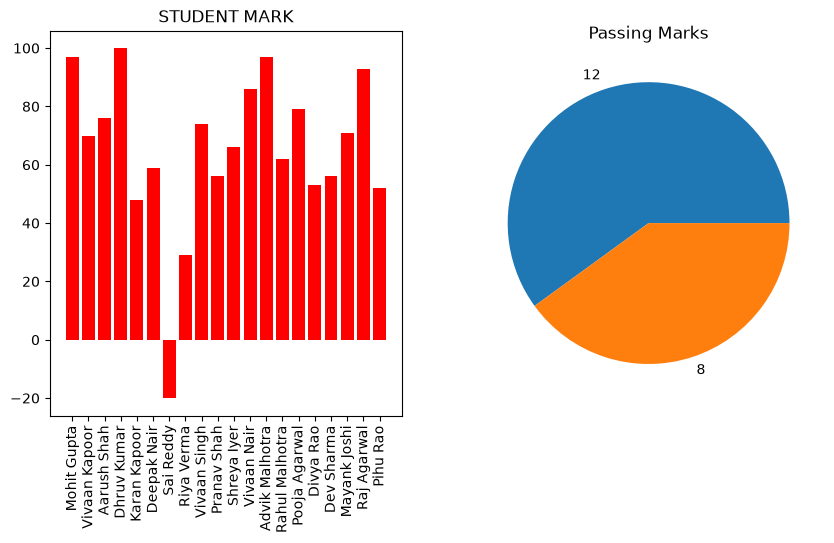

In [27]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 2,  figsize=(10, 5)) 

ax[0].bar(x=df_student.Student_Name, height=df_student.Marks, color='red')

ax[0].set_title("STUDENT MARK")
ax[0].set_xticklabels(df_student.Student_Name, rotation=90)

passes_count = df_student.Pass.value_counts()
ax[1].pie(passes_count, labels=passes_count)
ax[1].set_title("Passing Marks")

fig.show()

<Axes: xlabel='Student_Name'>

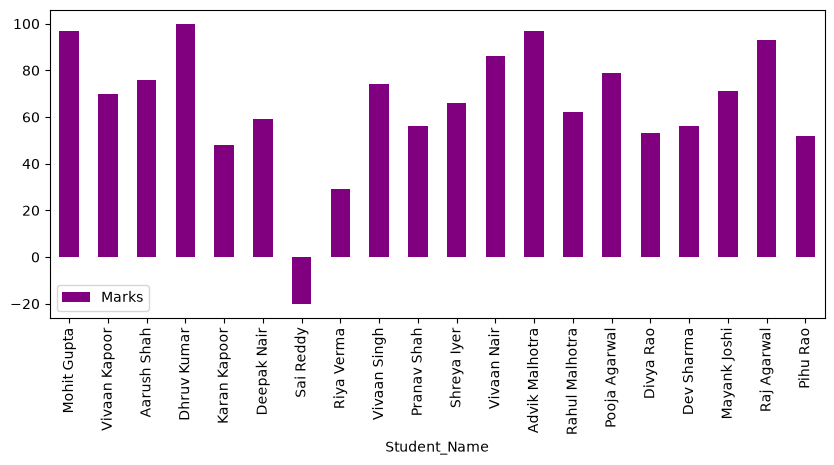

In [28]:
df_student.plot.bar(x='Student_Name', y='Marks', color='purple', figsize=(10, 4))

Minimum: -20.0
Maximum: 100.0
Median: 65.2
Median: 68.0
Mode: 56.0


C:\Users\USER\AppData\Local\Temp\ipykernel_24192\1832726904.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


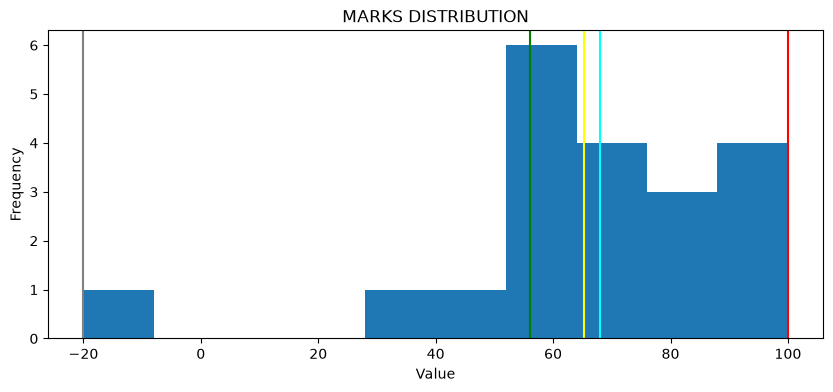

In [31]:
Marks = df_student.Marks

min_val = df_student.Marks.min()
max_val = df_student.Marks.max()
mean_val = df_student.Marks.mean()
median_val = df_student.Marks.median()
mode_val = df_student.Marks.mode()[0]

print(f'Minimum: {min_val}\nMaximum: {max_val}\nMedian: {mean_val}\nMedian: {median_val}\nMode: {mode_val}')

fig = plt.figure(figsize=(10, 4))

plt.hist(Marks)

plt.axvline(x=min_val, color='grey')
plt.axvline(x=max_val, color='red')
plt.axvline(mean_val, color='yellow')
plt.axvline(median_val, color='cyan')
plt.axvline(mode_val, color='green')

plt.title('MARKS DISTRIBUTION')
plt.xlabel('Value')
plt.ylabel('Frequency')

fig.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_24192\2045078984.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


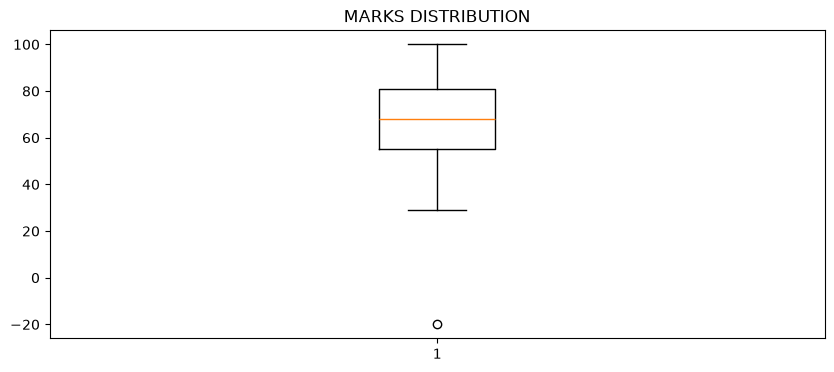

In [33]:
marks = df_student.Marks

fig = plt.figure(figsize=(10, 4))

plt.boxplot(marks)

plt.title("MARKS DISTRIBUTION")

fig.show()

In [ ]:
# create a fumction that we can re-use 
def show_distribution(var_data):
    from matplotlib import pyolot as plt 

# Get statistic
min-val = var_data.min()
max_val = var_data.max
mean_val = var_data.mean()
median_val = var_data.median()
mode_val = var_data.mode()

print('Minimum:{:.2f}\nMean:{:.2f}\nMedian:{:.2f}\nMode:{:.2f}\nMaximum:{:.2f}')




# Create a figure for 2 subplot (2 rows, 1 column)
fig, ax = plt.subplot(2, 1, figure=(10, 4))

# Add lines for the mean, median, and mode
ax[0].axvline(x=min_val, color= 'grey', linestyle='dashed', linewidth=2)
ax[0].axvline(x=max_val, color= 'red', linestyle='dashed', linewidth=2)
ax[0].axvline(x=mean_val, color= 'yellow', linestyle='dashed', linewidth=2)
ax[0].axvline(x=median_val, color= 'cyan', linestyle='dashed', linewidth=2)
ax[0].axvline(x=mode_val, color= 'green', linestyle='dashed', linewidth=2)

# Plot the boxplot 
ax[1].boxplot(var_data, vert=False)
ax[1].set_xlabel('Value')

# Add a title to the Figure
fig.suptitle('MARKS DISTRIBUTION')

# Show the Figure
fig.show()